In [1]:
!pip -q install kagglehub wfdb nltk

import os, re, glob, shutil, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.signal import butter, filtfilt, find_peaks
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import classification_report
from PIL import Image

sns.set_theme(style="whitegrid")
np.random.seed(42)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 932.6 kB/s eta 0:00:00


In [2]:
import urllib.request

pima_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
pima_path = "/content/pima-indians-diabetes.csv"

urllib.request.urlretrieve(pima_url, pima_path)

columns = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
]

df = pd.read_csv(pima_path, names=columns)
print("Shape:", df.shape)
df.head()


Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


A. Pima Indians Diabetes Dataset

In [3]:
print("Data types:")
print(df.dtypes)

print("\nMissing values before cleaning:")
print(df.isna().sum())

zero_as_missing = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
print("\nZero counts in clinical fields:")
print((df[zero_as_missing] == 0).sum())


Data types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Missing values before cleaning:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Zero counts in clinical fields:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


Clean implausible/missing-looking clinical values

In [4]:
df_clean = df.copy()

# Treat zero as missing in clinical measurements where zero is not physiologically meaningful.
df_clean[zero_as_missing] = df_clean[zero_as_missing].replace(0, np.nan)

print("Missing values after converting invalid zeros to NaN:")
print(df_clean.isna().sum())

# Median imputation is robust to skewed clinical variables.
for col in zero_as_missing:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("\nMissing values after imputation:")
print(df_clean.isna().sum())


Missing values after converting invalid zeros to NaN:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

Missing values after imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


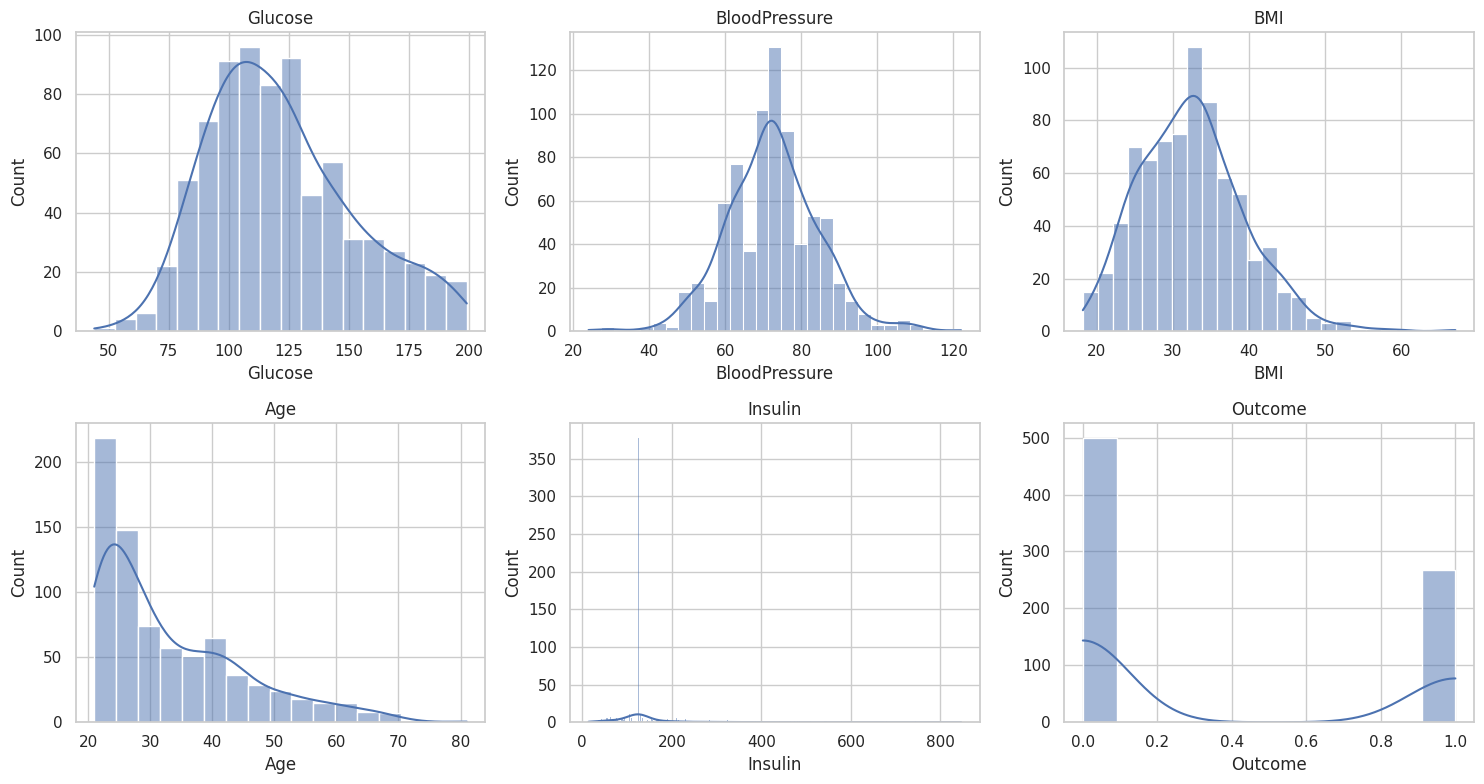

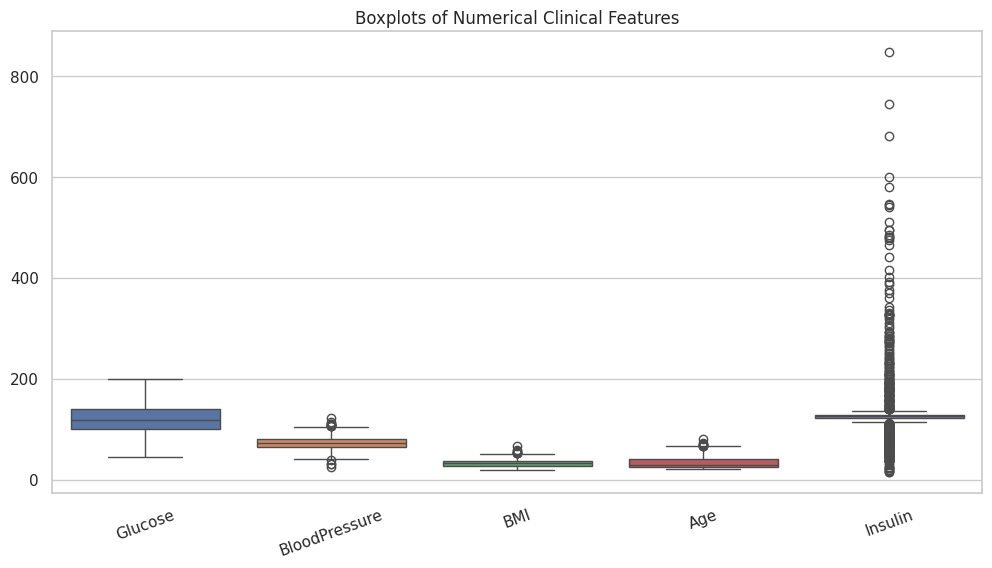

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), ["Glucose", "BloodPressure", "BMI", "Age", "Insulin", "Outcome"]):
    sns.histplot(df_clean[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_clean[["Glucose", "BloodPressure", "BMI", "Age", "Insulin"]])
plt.xticks(rotation=20)
plt.title("Boxplots of Numerical Clinical Features")
plt.show()


Outlier treatment and feature engineering

In [6]:
def remove_iqr_outliers(data, cols, k=1.5):
    result = data.copy()
    mask = pd.Series(True, index=result.index)
    for c in cols:
        q1 = result[c].quantile(0.25)
        q3 = result[c].quantile(0.75)
        iqr = q3 - q1
        lower, upper = q1 - k*iqr, q3 + k*iqr
        mask &= result[c].between(lower, upper)
    return result.loc[mask].copy()

numeric_for_outliers = ["Glucose", "BloodPressure", "BMI", "Age"]
before_rows = len(df_clean)
df_clean = remove_iqr_outliers(df_clean, numeric_for_outliers)
print("Rows before outlier removal:", before_rows)
print("Rows after outlier removal:", len(df_clean))

# Feature engineering
df_clean["BMI_Age_Interaction"] = df_clean["BMI"] * df_clean["Age"]

# Age groups
df_clean["Age_Group"] = pd.cut(
    df_clean["Age"],
    bins=[-np.inf, 40, 60, np.inf],
    labels=["<40", "40-60", ">60"],
    right=False
)

df_clean.head()


Rows before outlier removal: 768
Rows after outlier removal: 739


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Age_Interaction,Age_Group
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1,1680.0,40-60
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0,824.6,<40
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1,745.6,<40
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,590.1,<40
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,1422.3,<40


Feature selection and normalization

In [7]:
X = df_clean.drop(columns=["Outcome", "Age_Group"])
y = df_clean["Outcome"]

# Select the five most informative features using chi-square after min-max scaling.
X_nonnegative = MinMaxScaler().fit_transform(X)
selector = SelectKBest(score_func=chi2, k=min(5, X.shape[1]))
X_selected = selector.fit_transform(X_nonnegative, y)

selected_features = X.columns[selector.get_support()]
print("Selected features:", list(selected_features))

# Normalize numerical features to 0–1.
scaler = MinMaxScaler()
df_model = df_clean.copy()
numeric_cols = [c for c in df_model.columns if c not in ["Outcome", "Age_Group"]]
df_model[numeric_cols] = scaler.fit_transform(df_model[numeric_cols])

df_model.head()


Selected features: ['Pregnancies', 'Glucose', 'BMI', 'Age', 'BMI_Age_Interaction']


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Age_Interaction,Age_Group
0,0.352941,0.670968,0.50000,0.304348,0.132371,0.484277,0.243892,0.644444,1,0.560653,40-60
1,0.058824,0.264516,0.40625,0.239130,0.132371,0.264151,0.121279,0.222222,0,0.191118,<40
2,0.470588,0.896774,0.37500,0.239130,0.132371,0.160377,0.263883,0.244444,1,0.156990,<40
3,0.058824,0.290323,0.40625,0.173913,0.095066,0.311321,0.039538,0.000000,0,0.089813,<40
4,0.000000,0.600000,0.00000,0.304348,0.184116,0.783019,0.981786,0.266667,1,0.449326,<40


In [8]:
# Hypothesis test: glucose by diabetes outcome
g0 = df_clean.loc[df_clean["Outcome"] == 0, "Glucose"]
g1 = df_clean.loc[df_clean["Outcome"] == 1, "Glucose"]

t_stat, p_t = stats.ttest_ind(g0, g1, equal_var=False)
print("T-test: glucose by outcome")
print("t-statistic =", t_stat)
print("p-value     =", p_t)

# Chi-square test: age group vs outcome
ct = pd.crosstab(df_clean["Age_Group"], df_clean["Outcome"])
chi2_stat, p_chi, dof, expected = stats.chi2_contingency(ct)
print("\nChi-square test: age group vs outcome")
print("chi2 =", chi2_stat, "p-value =", p_chi)

# ANOVA: glucose across age groups
groups = [
    df_clean.loc[df_clean["Age_Group"] == g, "Glucose"].dropna()
    for g in ["<40", "40-60", ">60"]
]
f_stat, p_anova = stats.f_oneway(*groups)
print("\nOne-way ANOVA: glucose across age groups")
print("F-statistic =", f_stat)
print("p-value     =", p_anova)


T-test: glucose by outcome
t-statistic = -14.655643025678609
p-value     = 8.064173158233137e-40

Chi-square test: age group vs outcome
chi2 = 45.161201319002316 p-value = 1.5608807892744578e-10

One-way ANOVA: glucose across age groups
F-statistic = 18.10019032361044
p-value     = 2.1202715822467036e-08


Final tabular validation

Final shape: (739, 11)

Final missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
BMI_Age_Interaction         0
Age_Group                   0
dtype: int64

Summary statistics:


,count,mean,std,min,25%,50%,75%,max
Pregnancies,739.0,0.224389,0.196718,0.0,0.058824,0.176471,0.352941,1.0
Glucose,739.0,0.498913,0.194998,0.0,0.354839,0.470968,0.619355,1.0
BloodPressure,739.0,0.499133,0.170868,0.0,0.375000,0.500000,0.625000,1.0
SkinThickness,739.0,0.238910,0.094714,0.0,0.195652,0.239130,0.271739,1.0
Insulin,739.0,0.151244,0.102450,0.0,0.128761,0.132371,0.137786,1.0
BMI,739.0,0.439758,0.200732,0.0,0.292453,0.443396,0.569182,1.0
DiabetesPedigreeFunction,739.0,0.174175,0.145391,0.0,0.073745,0.129720,0.243003,1.0
Age,739.0,0.261013,0.246231,0.0,0.066667,0.177778,0.422222,1.0
Outcome,739.0,0.346414,0.476149,0.0,0.000000,0.000000,1.000000,1.0
BMI_Age_Interaction,739.0,0.291930,0.179956,0.0,0.155435,0.253499,0.407292,1.0


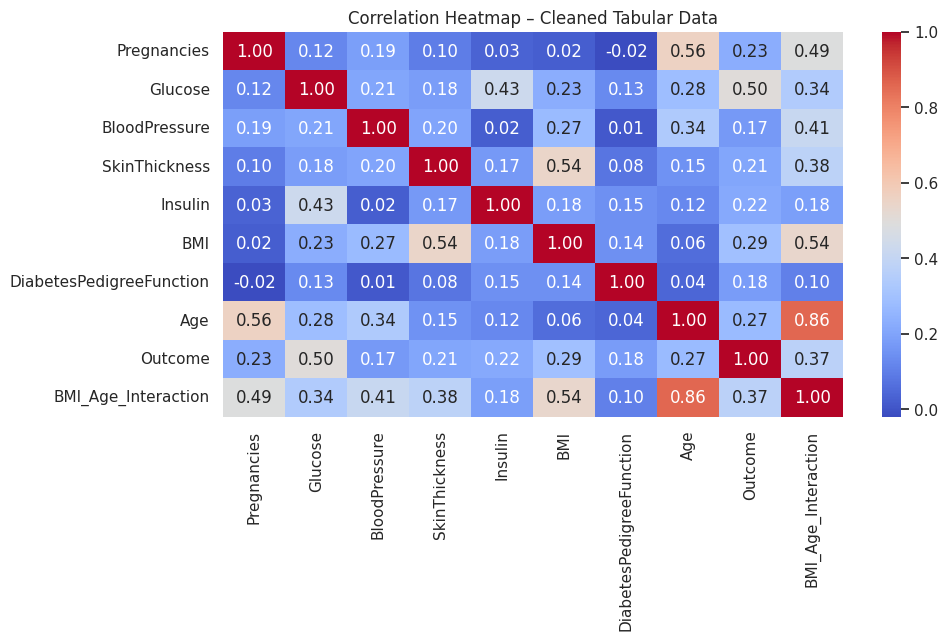

In [9]:
print("Final shape:", df_model.shape)
print("\nFinal missing values:")
print(df_model.isna().sum())

print("\nSummary statistics:")
display(df_model.describe().T)

plt.figure(figsize=(10, 5))
sns.heatmap(df_model.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap – Cleaned Tabular Data")
plt.show()


B.  Textual Data: MTSamples Medical Transcriptions

In [10]:
import kagglehub

mts_dir = kagglehub.dataset_download("tboyle10/medicaltranscriptions")
print("Downloaded to:", mts_dir)

csv_files = glob.glob(os.path.join(mts_dir, "**", "*.csv"), recursive=True)
print("CSV files:", csv_files[:10])

mts_csv = csv_files[0]
text_df = pd.read_csv(mts_csv)

print("Shape:", text_df.shape)
display(text_df.head())
print(text_df.columns.tolist())


Using Colab cache for faster access to the 'medicaltranscriptions' dataset.
Downloaded to: /kaggle/input/medicaltranscriptions
CSV files: ['/kaggle/input/medicaltranscriptions/mtsamples.csv']
Shape: (4999, 6)


,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


['Unnamed: 0', 'description', 'medical_specialty', 'sample_name', 'transcription', 'keywords']


In [11]:
text_df = text_df.copy()
text_col = "transcription" if "transcription" in text_df.columns else text_df.columns[-1]

def clean_medical_text(text):
    text = "" if pd.isna(text) else str(text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"\b[\w.-]+@[\w.-]+\.\w+\b", " [EMAIL] ", text)
    text = re.sub(r"\b(?:\+?\d{1,3}[-. ]?)?(?:\(?\d{3}\)?[-. ]?)\d{3}[-. ]?\d{4}\b", " [PHONE] ", text)
    text = re.sub(r"\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b", " [DATE] ", text)
    text = re.sub(r"\b(?:MRN|ID|PATIENT\s*ID)\s*[:#-]?\s*\w+\b", " [PATIENT_ID] ", text, flags=re.I)
    text = re.sub(r"\s+", " ", text)
    return text.strip().lower()

text_df["clean_text"] = text_df[text_col].apply(clean_medical_text)
text_df["text_length"] = text_df["clean_text"].str.len()
text_df["word_count"] = text_df["clean_text"].str.split().str.len()

display(text_df[[text_col, "clean_text", "word_count"]].head())


,transcription,clean_text,word_count
0,"SUBJECTIVE:, This 23-year-old white female pr...","subjective:, this 23-year-old white female pre...",204
1,"PAST MEDICAL HISTORY:, He has difficulty climb...","past medical history:, he has difficulty climb...",350
2,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","history of present illness: , i have seen abc ...",716
3,"2-D M-MODE: , ,1. Left atrial enlargement wit...","2-d m-mode: , ,1. left atrial enlargement with...",68
4,1. The left ventricular cavity size and wall ...,1. the left ventricular cavity size and wall t...,229


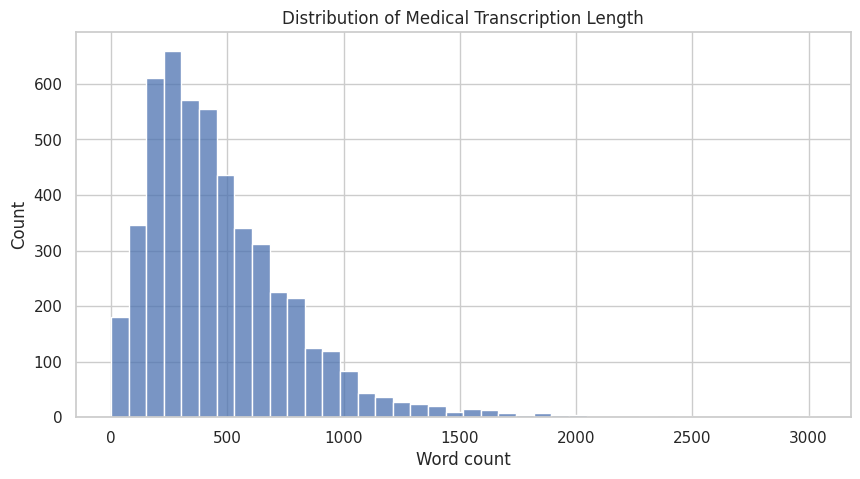

TF-IDF matrix shape: (4966, 1000)
Top TF-IDF terms:
['patient' 'right' 'left' 'history' 'procedure' 'normal' 'placed' 'pain'
 'mg' 'noted' 'using' 'time' 'diagnosis' 'anesthesia' 'blood' 'skin'
 'performed' 'incision' 'removed' 'used']


In [12]:
plt.figure(figsize=(10, 5))
sns.histplot(text_df["word_count"], bins=40)
plt.title("Distribution of Medical Transcription Length")
plt.xlabel("Word count")
plt.show()

# Remove empty records
text_df = text_df[text_df["clean_text"].str.len() > 0].copy()

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=1000,
    ngram_range=(1, 2),
    min_df=2
)

X_text = vectorizer.fit_transform(text_df["clean_text"])
print("TF-IDF matrix shape:", X_text.shape)

feature_names = np.array(vectorizer.get_feature_names_out())
mean_scores = np.asarray(X_text.mean(axis=0)).ravel()
top_idx = mean_scores.argsort()[-20:][::-1]

print("Top TF-IDF terms:")
print(feature_names[top_idx])


In [13]:
if "medical_specialty" in text_df.columns:
    text_df["medical_specialty"] = text_df["medical_specialty"].fillna("Unknown")
    print(text_df["medical_specialty"].value_counts().head(10))
else:
    print("No medical_specialty column was found; text preprocessing is still complete.")


medical_specialty
Surgery                          1088
Consult - History and Phy.        516
Cardiovascular / Pulmonary        371
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  224
Neurology                         223
SOAP / Chart / Progress Notes     166
Urology                           156
Name: count, dtype: int64


C. Image Data: Chest X-Ray (Pneumonia)

In [14]:
xray_dir = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("Downloaded to:", xray_dir)

# Locate train directories
candidate_train = glob.glob(os.path.join(xray_dir, "**", "train"), recursive=True)
train_dir = candidate_train[0] if candidate_train else os.path.join(xray_dir, "chest_xray", "train")
print("Train directory:", train_dir)

normal_files = glob.glob(os.path.join(train_dir, "NORMAL", "*.jpeg")) + glob.glob(os.path.join(train_dir, "NORMAL", "*.jpg"))
pneu_files = glob.glob(os.path.join(train_dir, "PNEUMONIA", "*.jpeg")) + glob.glob(os.path.join(train_dir, "PNEUMONIA", "*.jpg"))

print("Normal images:", len(normal_files))
print("Pneumonia images:", len(pneu_files))


Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Downloaded to: /kaggle/input/chest-xray-pneumonia
Train directory: /kaggle/input/chest-xray-pneumonia/chest_xray/train
Normal images: 1341
Pneumonia images: 3875


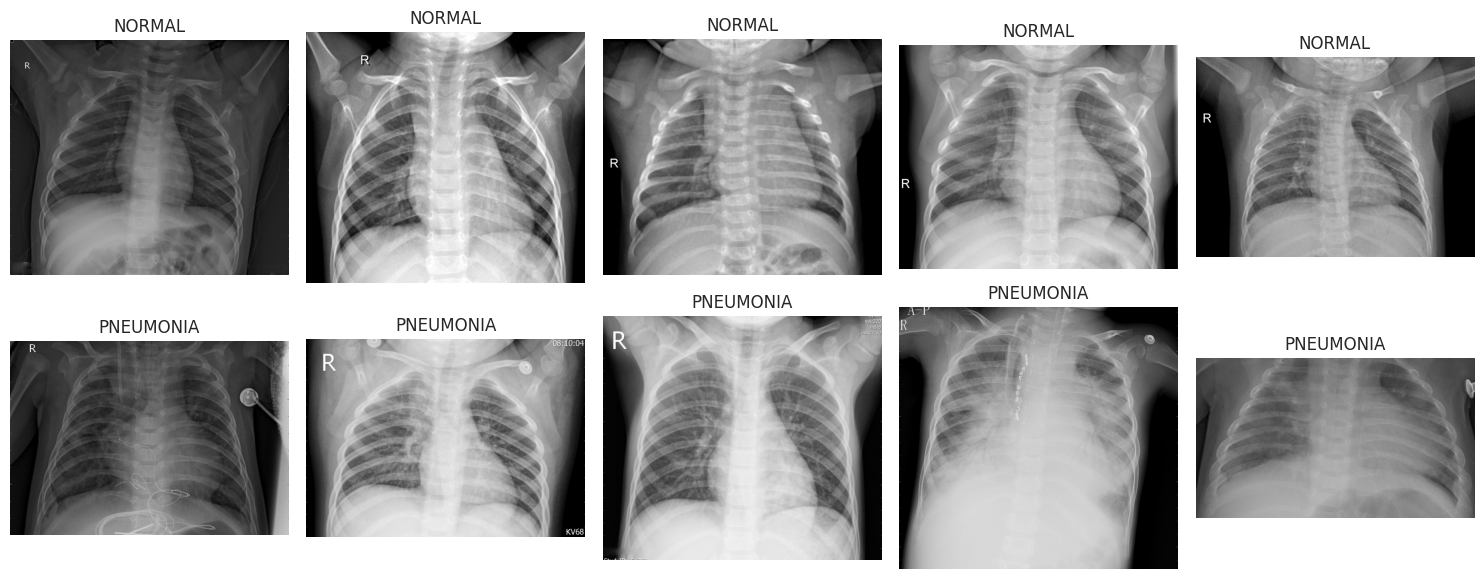

Image tensor shape: (10, 224, 224, 3)
Labels: [0 0 0 0 0 1 1 1 1 1]


In [15]:
from PIL import Image, ImageOps, ImageEnhance

sample_n = min(5, len(normal_files), len(pneu_files))
sample_paths = normal_files[:sample_n] + pneu_files[:sample_n]
sample_labels = ["NORMAL"] * sample_n + ["PNEUMONIA"] * sample_n

fig, axes = plt.subplots(2, sample_n, figsize=(15, 6))
for ax, path, label in zip(axes.ravel(), sample_paths, sample_labels):
    img = Image.open(path).convert("RGB")
    ax.imshow(img)
    ax.set_title(label)
    ax.axis("off")
plt.tight_layout()
plt.show()

# Convert to model-ready tensors; conversion also drops EXIF metadata from the image object.
IMG_SIZE = (224, 224)
image_tensors, image_labels = [], []

for path, label in zip(sample_paths, sample_labels):
    img = Image.open(path).convert("RGB")
    img = ImageOps.fit(img, IMG_SIZE)
    arr = np.asarray(img, dtype=np.float32) / 255.0
    image_tensors.append(arr)
    image_labels.append(0 if label == "NORMAL" else 1)

X_img = np.stack(image_tensors)
y_img = np.array(image_labels)

print("Image tensor shape:", X_img.shape)
print("Labels:", y_img)


,mean_intensity,std_intensity,min_intensity,max_intensity,label
0,0.316238,0.143078,0.000000,0.694118,0
1,0.582756,0.228650,0.000000,1.000000,0
2,0.547372,0.164588,0.000000,0.992157,0
3,0.627672,0.148544,0.003922,0.988235,0
4,0.541987,0.117386,0.125490,0.905882,0
5,0.326216,0.127351,0.062745,0.800000,1
6,0.692535,0.154966,0.137255,0.937255,1
7,0.644114,0.211071,0.003922,1.000000,1
8,0.564237,0.269039,0.000000,0.882353,1
9,0.525422,0.112082,0.192157,0.733333,1


Original tensor shape: (10, 224, 224, 3)
Augmented tensor shape: (10, 224, 224, 3)


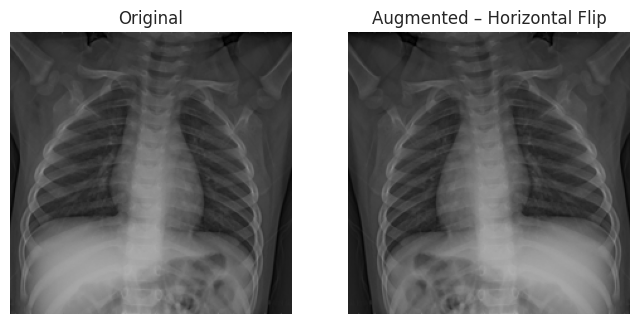

In [16]:
# Simple handcrafted features for EDA/feature extraction.
gray = np.mean(X_img, axis=3)
image_features = pd.DataFrame({
    "mean_intensity": gray.mean(axis=(1,2)),
    "std_intensity": gray.std(axis=(1,2)),
    "min_intensity": gray.min(axis=(1,2)),
    "max_intensity": gray.max(axis=(1,2)),
    "label": y_img
})
display(image_features)

# Lightweight augmentation: horizontal flip.
augmented = np.flip(X_img, axis=2)
print("Original tensor shape:", X_img.shape)
print("Augmented tensor shape:", augmented.shape)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(X_img[0])
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(augmented[0])
plt.title("Augmented – Horizontal Flip")
plt.axis("off")
plt.show()


D. Signal Data: MIT-BIH Arrhythmia Database

In [17]:
import wfdb

record_names = ["100", "101"]
records = {}

for rec in record_names:
    records[rec] = wfdb.rdrecord(rec, pn_dir="mitdb")
    print(
        rec,
        "sampling frequency =", records[rec].fs,
        "samples =", records[rec].sig_len,
        "channels =", records[rec].n_sig,
        "names =", records[rec].sig_name
    )


100 sampling frequency = 360 samples = 650000 channels = 2 names = ['MLII', 'V5']
101 sampling frequency = 360 samples = 650000 channels = 2 names = ['MLII', 'V1']


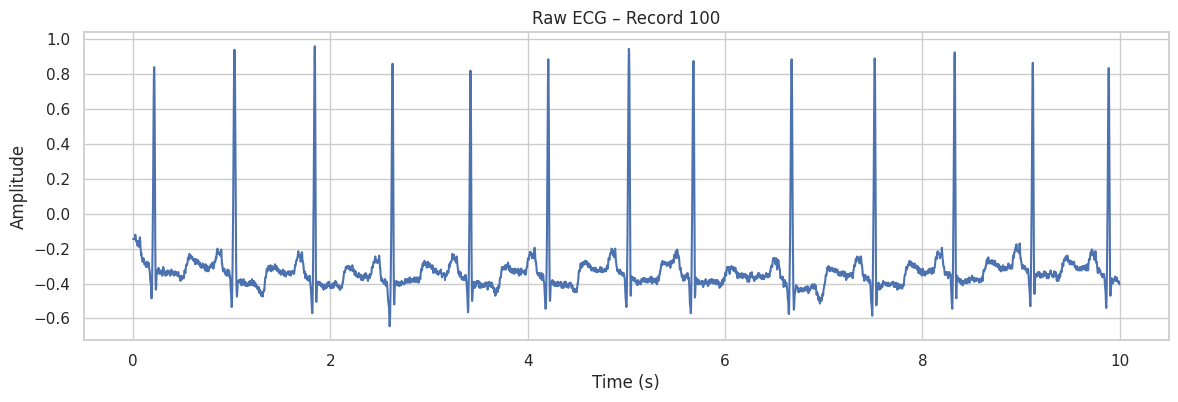

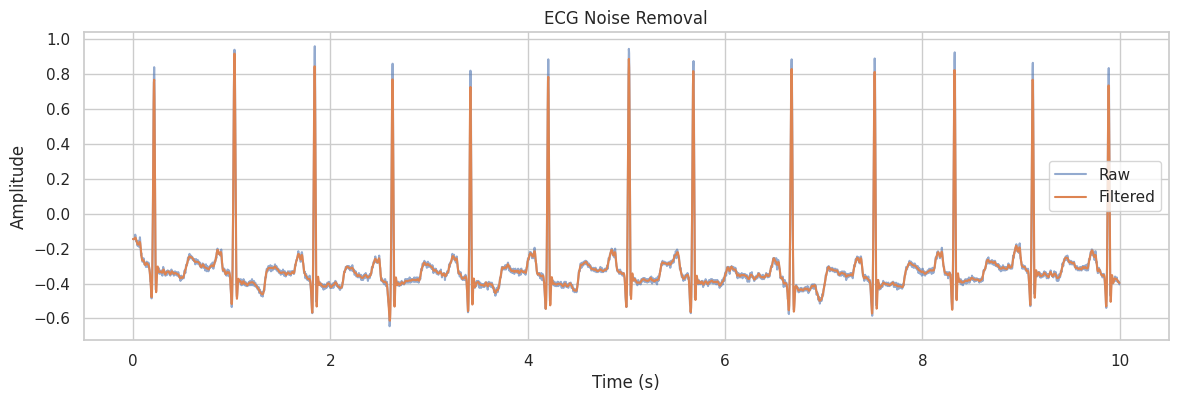

In [18]:
rec = records["100"]
signal = rec.p_signal[:, 0]
fs = rec.fs

seconds = 10
n = int(seconds * fs)

plt.figure(figsize=(14, 4))
plt.plot(np.arange(n) / fs, signal[:n])
plt.title("Raw ECG – Record 100")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

# Low-pass Butterworth filter
def lowpass_filter(x, fs, cutoff=40, order=4):
    b, a = butter(order, cutoff / (fs / 2), btype="low")
    return filtfilt(b, a, x)

filtered = lowpass_filter(signal, fs)

plt.figure(figsize=(14, 4))
plt.plot(np.arange(n) / fs, signal[:n], alpha=0.6, label="Raw")
plt.plot(np.arange(n) / fs, filtered[:n], label="Filtered")
plt.title("ECG Noise Removal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()


Number of extracted windows: 50


,peak_index,mean,std,rms,min,max,peak_to_peak
0,370,-0.316764,0.199511,0.374358,-0.518234,0.917697,1.435931
1,662,-0.332018,0.178289,0.376859,-0.566692,0.845299,1.411992
2,947,-0.330463,0.169366,0.371337,-0.613493,0.769693,1.383185
3,1231,-0.336806,0.160107,0.372925,-0.558586,0.726578,1.285164
4,1515,-0.325755,0.171149,0.367979,-0.545536,0.784447,1.329983


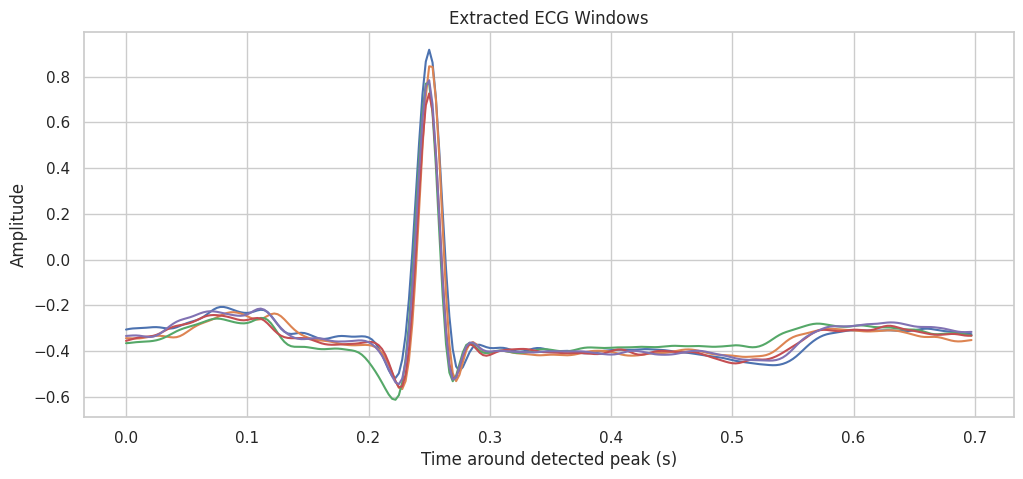

In [19]:
# Detect candidate R-peaks on the filtered signal.
peaks, properties = find_peaks(
    filtered,
    distance=int(0.25 * fs),
    prominence=np.std(filtered) * 0.5
)

# Keep peaks from a central section to avoid edge effects.
peaks = peaks[(peaks > int(0.5*fs)) & (peaks < len(filtered)-int(0.5*fs))]

window_left = int(0.25 * fs)
window_right = int(0.45 * fs)

windows = []
features = []

for p in peaks[:50]:
    w = filtered[p-window_left:p+window_right]
    if len(w) == window_left + window_right:
        windows.append(w)
        features.append({
            "peak_index": p,
            "mean": np.mean(w),
            "std": np.std(w),
            "rms": np.sqrt(np.mean(w**2)),
            "min": np.min(w),
            "max": np.max(w),
            "peak_to_peak": np.ptp(w)
        })

signal_features = pd.DataFrame(features)
print("Number of extracted windows:", len(windows))
display(signal_features.head())

if windows:
    plt.figure(figsize=(12, 5))
    for w in windows[:5]:
        plt.plot(np.arange(len(w))/fs, w)
    plt.title("Extracted ECG Windows")
    plt.xlabel("Time around detected peak (s)")
    plt.ylabel("Amplitude")
    plt.show()


In [20]:
if windows:
    W = np.array(windows)
    W_scaled = StandardScaler().fit_transform(W)
    print("Scaled window shape:", W_scaled.shape)
    print("Mean:", W_scaled.mean(), "Std:", W_scaled.std())
else:
    print("No windows were extracted; inspect peak detection parameters.")


Scaled window shape: (50, 252)
Mean: 2.5263741715914673e-16 Std: 1.0


**Final validation and** **observations**

In [21]:
print("===== FINAL VALIDATION =====")

print("\nA. TABULAR")
print("Rows:", len(df_model))
print("Missing values:", int(df_model.isna().sum().sum()))
print("Outcome distribution:")
print(df_model["Outcome"].value_counts())

print("\nB. TEXT")
print("Records:", len(text_df))
print("Empty cleaned texts:", int((text_df["clean_text"].str.len() == 0).sum()))
print("TF-IDF shape:", X_text.shape)

print("\nC. IMAGE")
print("Processed image tensor shape:", X_img.shape)
print("Image pixel range:", X_img.min(), "to", X_img.max())

print("\nD. SIGNAL")
print("Records processed:", list(records.keys()))
print("Sampling frequency:", fs, "Hz")
print("Extracted windows:", len(windows))


===== FINAL VALIDATION =====

A. TABULAR
Rows: 739
Missing values: 0
Outcome distribution:
Outcome
0    483
1    256
Name: count, dtype: int64

B. TEXT
Records: 4966
Empty cleaned texts: 0
TF-IDF shape: (4966, 1000)

C. IMAGE
Processed image tensor shape: (10, 224, 224, 3)
Image pixel range: 0.0 to 1.0

D. SIGNAL
Records processed: ['100', '101']
Sampling frequency: 360 Hz
Extracted windows: 50


**Conclusion**

The four healthcare data modalities were acquired and processed using modality-specific methods. Tabular data was cleaned, missing-looking clinical values were imputed, outliers were handled, features were engineered and selected, normalized, and analyzed using hypothesis, chi-square, and ANOVA tests. Medical transcriptions were cleaned, simple PHI-style patterns were removed, and TF-IDF features were extracted. Chest X-ray images were resized, normalized, inspected, and augmented while avoiding retention of image metadata in processed copies. ECG signals from MIT-BIH were filtered to reduce high-frequency noise, segmented into windows, and converted into numerical features.
The experiment demonstrates that healthcare data requires different preprocessing strategies for different modalities and that privacy, clinical plausibility, class imbalance, image metadata, and signal noise must be considered before machine-learning analysis.